# Task 5 – Đề xuất hành động cho ITB

Notebook này ghép các phát hiện của Task 1–4 thành một kế hoạch hành động không mang tính trừng phạt, dùng cho slide 20–21. Mỗi con số nhắc tới trong phần chữ đều được tính ngay ở ô code phía trên nó.

Đề yêu cầu:

1. Đúng **6 đề xuất**, mỗi đề xuất cho một loại công cụ: công cụ lập ngân sách, cảnh báo chi tiêu, nhắc kế hoạch tài chính, nội dung giáo dục tài chính, khuyến khích dùng kênh số, gợi ý sản phẩm phù hợp.
2. Mỗi đề xuất dựa trên **một phát hiện thật** từ dữ liệu, gắn với một con số hoặc một cột cụ thể.
3. Mỗi đề xuất có **nhóm khách mục tiêu** với số khách và tỷ lệ chính xác.
4. **Xếp hạng** các đề xuất theo độ phủ và theo mức độ mạnh của yếu tố tác động.
5. Một câu tuyên bố rõ: **financial_health_score không bao giờ được dùng để từ chối cho vay, giảm hạn mức hay khóa tài khoản.**

Cách đọc notebook:

- **Phần 0.** Chuẩn bị dữ liệu và các mẫu số dùng chung
- **Phần 1.** Sáu đề xuất, mỗi đề xuất một mục: phát hiện, nhóm mục tiêu, cách làm, cách đo
- **Phần 2.** Bảng tổng hợp và xếp hạng
- **Phần 3.** Độ phủ chung và phần trùng giữa các đề xuất
- **Phần 4.** Quy tắc tín dụng và các kiểm tra an toàn

**Quy ước về mẫu số.** Số khách mục tiêu luôn tính trên **999 khách**, vì chương trình của ITB áp dụng cho mọi khách. Các con số dùng để chứng minh phát hiện được tính trên **908 khách có đủ 12 tháng**, giống Task 2, để so sánh công bằng. Mỗi tỷ lệ đều ghi rõ mẫu số.

**Nguồn dữ liệu.** Hai file gốc trong `data/`; danh sách 64 khách và bảng gộp nghề lấy từ `task2_financial_health/outputs/`; kết quả phân nhóm của Task 4 lấy từ `inputs/task4_customer_segmentation_final.csv` (xuất từ notebook Task 4 bản nộp: K-Means K = 4 trên 908 khách đủ năm, cộng nhóm Limited-History 91 khách; chạy lại cho kết quả trùng khớp 100%); nhóm 59 khách của Task 3 được tính lại ngay trong notebook theo đúng quy tắc của Task 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA = Path('../data')
IN = Path('inputs')
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
CH = Path('charts'); CH.mkdir(exist_ok=True)
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)

RED, BLUE, GRAY, LGRAY = '#e34948', '#2a78d6', '#9b9a94', '#d9d8d3'
INK, INK2 = '#0b0b0b', '#52514e'
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.edgecolor': LGRAY, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': INK2, 'ytick.color': INK2, 'legend.frameon': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

def save(fig, name):
    fig.savefig(CH / f'{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

cm = pd.read_csv(DATA / 'consumer_financial_health_engagement_2025.csv')
cm['month'] = pd.to_datetime(cm['analysis_month']).dt.month
tx = pd.read_csv(DATA / 'consumer_transactions_2025.csv',
                 usecols=['consumer_id', 'spend_amount_vnd', 'spending_category',
                          'transaction_channel', 'transaction_month', 'transaction_hour'])
print('Bảng tháng:', cm.shape, '| Sổ giao dịch:', tx.shape)

Bảng tháng: (10992, 31) | Sổ giao dịch: (1852394, 6)


## Phần 0 – Chuẩn bị dữ liệu và các mẫu số dùng chung

Tạo một bảng theo khách, đánh dấu khách đủ 12 tháng, khách dưới 18 tuổi, và gắn mức điểm cho từng tháng theo 4 mức của đề: dưới 40, 40–60, 60–80, từ 80.

In [2]:
BANDS = ['<40', '40–60', '60–80', '≥80']
cm['band'] = pd.cut(cm['financial_health_score'], [0, 40, 60, 80, 100.01], right=False, labels=BANDS)

cust = cm.groupby('consumer_id').agg(
    n_months=('month', 'nunique'),
    age=('age', 'min'),
    occupation=('occupation', 'first'),
    health_avg=('financial_health_score', 'mean'),
    engagement_avg=('engagement_score', 'mean'),
    txn_per_month=('transaction_count', 'mean'),
    spend_to_income=('spend_to_income_ratio', 'mean'),
    months_overspend=('spend_to_income_ratio', lambda s: int((s > 1).sum())),
    ever_below_40=('financial_health_score', lambda s: bool((s < 40).any())),
    income_avg=('monthly_income_vnd', 'mean'),
    spend_avg=('total_spend_vnd', 'mean'),
)
cust['full_year'] = cust['n_months'].eq(12)
cust['under_18'] = cust['age'].lt(18)

N_ALL = len(cust)
N_FULL = int(cust['full_year'].sum())
full = cust[cust['full_year']].copy()
# Bách phân vị thu nhập và chi tiêu trong 908 khách đủ năm, giống Task 2 (không so trực tiếp bằng VND)
full['pct_income'] = full['income_avg'].rank(pct=True) * 100
full['pct_spend'] = full['spend_avg'].rank(pct=True) * 100

def reach(ids, base=N_ALL):
    n = len(ids)
    return f'{n / base * 100:.1f}% ({n} / {base})'

print('Tổng số khách:', N_ALL)
print('Khách đủ 12 tháng:', N_FULL)
print('Khách dưới 18 tuổi:', int(cust['under_18'].sum()))
print('Khách từng có ít nhất một tháng dưới 40:', reach(cust.index[cust['ever_below_40']]))

Tổng số khách: 999
Khách đủ 12 tháng: 908
Khách dưới 18 tuổi: 7
Khách từng có ít nhất một tháng dưới 40: 7.0% (70 / 999)


Có 999 khách, trong đó 908 khách có đủ 12 tháng. 7 khách dưới 18 tuổi sẽ không nhận bất kỳ gợi ý nào liên quan đến tín dụng hay trả góp. 70 khách (7,0% trên 999) từng có ít nhất một tháng điểm sức khỏe dưới 40.

Tiếp theo gắn thu nhập tháng vào từng giao dịch để đánh dấu **giao dịch lớn**: giao dịch từ 20% thu nhập tháng của chính khách đó trở lên, đúng định nghĩa đã thống nhất ở Task 2.

In [3]:
t = tx.merge(cm[['consumer_id', 'month', 'monthly_income_vnd', 'band']],
             left_on=['consumer_id', 'transaction_month'], right_on=['consumer_id', 'month'])
t['big'] = t['spend_amount_vnd'] >= 0.2 * t['monthly_income_vnd']
t['full_year'] = t['consumer_id'].map(cust['full_year'])
print('Số giao dịch sau khi gắn thu nhập:', len(t), '| khớp với sổ giao dịch:', len(t) == len(tx))
print('Số giao dịch lớn:', int(t['big'].sum()))

Số giao dịch sau khi gắn thu nhập: 1852394 | khớp với sổ giao dịch: True
Số giao dịch lớn: 807


## Phần 1 – Sáu đề xuất

Mỗi mục đi theo cùng một thứ tự: **phát hiện** từ task trước, **nhóm mục tiêu** và số khách, **cách làm**, **cách đo** kết quả. Ô code tính cả số khách mục tiêu lẫn con số dùng để xếp hạng mức độ mạnh của yếu tố tác động.

**Cách đo mức độ mạnh.** Mỗi đề xuất nhắm vào một dấu hiệu cụ thể. Mức độ mạnh là **tín hiệu đó xuất hiện nhiều gấp bao nhiêu lần** ở nhóm có vấn đề so với nhóm so sánh. Ví dụ, nếu tháng căng thẳng có giao dịch lớn thường xuyên gấp 80 lần tháng bình thường, thì giao dịch lớn là dấu hiệu rất mạnh để cảnh báo. Con số này cho biết đề xuất nhắm đúng chỗ đến mức nào, không phải là bằng chứng nhân quả.

### Đề xuất 1 – Cảnh báo chi tiêu: báo ngay khi một giao dịch vượt 20% thu nhập tháng

In [4]:
# Phát hiện (Task 2): tỷ lệ tháng có ít nhất một giao dịch lớn, theo mức điểm của tháng, trên 908 khách đủ năm
mb = (t[t['full_year']].groupby(['consumer_id', 'month', 'band'], observed=True)['big'].any()
      .reset_index().groupby('band', observed=True)['big'].mean() * 100)
print('% số tháng có ít nhất một giao dịch từ 20% thu nhập tháng (908 khách đủ năm):')
print(mb.round(1).to_string())

# Buổi tối
tf = t[t['full_year']]
eve = tf.assign(evening=tf['transaction_hour'] >= 18).groupby(['band', 'evening'], observed=True)['spend_amount_vnd'].sum().unstack()
eve_share = eve[True] / eve.sum(axis=1) * 100
print('\n% chi tiêu rơi vào 18–24 giờ:', eve_share.round(1).to_dict())

target_alert = set(t.loc[t['big'], 'consumer_id'])
priority_alert = target_alert & set(cust.index[cust['ever_below_40']])
driver_alert = mb['<40'] / mb['60–80']
print('\nNhóm mục tiêu – khách có ít nhất một giao dịch lớn:', reach(target_alert))
print('Ưu tiên trước – trong đó từng có tháng dưới 40:', reach(priority_alert))
print('Khách từng dưới 40 nhưng không có giao dịch lớn nào:', int(cust['ever_below_40'].sum()) - len(priority_alert))
print(f'Mức độ mạnh: {mb["<40"]:.1f}% / {mb["60–80"]:.1f}% = {driver_alert:.0f} lần')

% số tháng có ít nhất một giao dịch từ 20% thu nhập tháng (908 khách đủ năm):
band
<40      73.4
40–60    20.6
60–80     0.9
≥80       0.0



% chi tiêu rơi vào 18–24 giờ: {'<40': 39.7, '40–60': 32.0, '60–80': 28.1, '≥80': 25.4}

Nhóm mục tiêu – khách có ít nhất một giao dịch lớn: 38.9% (389 / 999)
Ưu tiên trước – trong đó từng có tháng dưới 40: 6.1% (61 / 999)
Khách từng dưới 40 nhưng không có giao dịch lớn nào: 9
Mức độ mạnh: 73.4% / 0.9% = 79 lần


- **Phát hiện (Task 2).** 73,4% số tháng có điểm dưới 40 chứa ít nhất một giao dịch từ 20% thu nhập tháng trở lên, trong khi ở tháng 60–80 chỉ có 0,9% (908 khách đủ năm). Giao dịch lớn xuất hiện ở tháng căng thẳng thường xuyên gấp khoảng 79 lần tháng bình thường. Tháng căng thẳng cũng dồn 39,7% chi tiêu vào 18–24 giờ, so với 28,1% ở tháng 60–80. Cột dữ liệu: `spend_amount_vnd`, `monthly_income_vnd`, `transaction_hour`.
- **Nhóm mục tiêu.** 389 khách từng có ít nhất một giao dịch như vậy, chiếm 38,9% (389 / 999). Triển khai trước cho 61 khách trong số đó từng có tháng dưới 40, chiếm 6,1% (61 / 999). Đây là 61 trong 70 khách từng có tháng dưới 40; 9 khách còn lại rơi xuống dưới 40 mà không có giao dịch lớn nào, nên cảnh báo này không chạm tới họ.
- **Cách làm.** Gửi thông báo trong app ngay lúc thanh toán khi một giao dịch vượt 20% thu nhập tháng của chính khách đó, kèm số tiền còn lại so với thu nhập tháng. Mốc tính theo thu nhập từng người, không dùng một mức VND chung. Vì chi tiêu tháng căng thẳng dồn vào buổi tối, thông báo phải gửi tức thì, không đợi sao kê cuối tháng. Khách tự chỉnh mốc hoặc tắt được.
- **Cách đo.** Trong số khách nhận cảnh báo, tỷ lệ tháng có điểm dưới 40 có giảm so với nhóm chưa nhận không.

### Đề xuất 2 – Nhắc kế hoạch tài chính: nhắc từ tháng 11 trước mùa chi tiêu cuối năm

In [5]:
fm = cm[cm['consumer_id'].isin(full.index)]
over_by_month = fm.groupby('month')['spend_to_income_ratio'].apply(lambda s: (s > 1).mean() * 100)
print('% khách chi vượt thu nhập theo tháng (908 khách đủ năm):')
print(over_by_month.round(1).to_string())

low = fm[fm['financial_health_score'] < 40]
n_low, n_decjan = len(low), int(low['month'].isin([12, 1]).sum())
share_decjan = n_decjan / n_low * 100
driver_plan = share_decjan / (2 / 12 * 100)

# Task 1 Q1: tháng 12 chiếm bao nhiêu % tổng chi tiêu cả năm (toàn bộ dữ liệu)
spend_m = cm.groupby('month')['total_spend_vnd'].sum()
dec_share = spend_m[12] / spend_m.sum() * 100

dec = cm[cm['month'] == 12]
target_plan = set(dec.loc[dec['spend_to_income_ratio'] > 1, 'consumer_id'])
print(f'\nTháng 12 chiếm {dec_share:.2f}% tổng chi tiêu cả năm')
print(f'Tháng 12 và tháng 1 chiếm {n_decjan} / {n_low} lần điểm dưới 40 = {share_decjan:.1f}%')
print('Nhóm mục tiêu – khách chi vượt thu nhập trong tháng 12:', reach(target_plan),
      f'| trên số khách có dữ liệu tháng 12: {len(target_plan) / dec["consumer_id"].nunique() * 100:.1f}% ({len(target_plan)} / {dec["consumer_id"].nunique()})')
print(f'Mức độ mạnh: {share_decjan:.1f}% / {2 / 12 * 100:.1f}% (nếu dàn đều 2 trên 12 tháng) = {driver_plan:.1f} lần')

% khách chi vượt thu nhập theo tháng (908 khách đủ năm):
month
1      2.5
2      2.0
3      6.6
4      5.0
5      6.5
6     16.6
7     13.1
8     15.9
9      5.8
10     5.6
11     6.5
12    75.7

Tháng 12 chiếm 15.04% tổng chi tiêu cả năm
Tháng 12 và tháng 1 chiếm 46 / 94 lần điểm dưới 40 = 48.9%
Nhóm mục tiêu – khách chi vượt thu nhập trong tháng 12: 68.8% (687 / 999) | trên số khách có dữ liệu tháng 12: 74.8% (687 / 918)
Mức độ mạnh: 48.9% / 16.7% (nếu dàn đều 2 trên 12 tháng) = 2.9 lần


- **Phát hiện (Task 1 và Task 2).** Tháng 12 chiếm 15,04% tổng chi tiêu cả năm, cao nhất trong năm (Task 1, câu 1). Trong tháng 12, 75,7% khách chi vượt thu nhập, trong khi các tháng khác chỉ từ 2,0% đến 16,6% (908 khách đủ năm). Tháng 12 và tháng 1 chiếm 46 trên 94 lần điểm dưới 40, tức 48,9%, gần gấp 3 lần mức 16,7% nếu các lần căng thẳng rải đều cho 12 tháng. Cột dữ liệu: `analysis_month`, `spend_to_income_ratio`, `total_spend_vnd`.
- **Nhóm mục tiêu.** 687 khách đã chi vượt thu nhập trong tháng 12, chiếm 68,8% (687 / 999), hay 74,8% trên 918 khách có dữ liệu tháng 12.
- **Cách làm.** Từ đầu tháng 11, gửi lời nhắc lập kế hoạch chi tiêu cho tháng 12 và Tết, kèm tổng chi tháng 12 năm trước so với thu nhập của chính khách đó. Sau Tết, gửi một bản tóm tắt tháng 1 để khách thấy mình đã chi bao nhiêu.
- **Cách đo.** Tỷ lệ khách chi vượt thu nhập trong tháng 12 năm sau ở nhóm nhận nhắc so với nhóm chưa nhận.

### Đề xuất 3 – Công cụ lập ngân sách trong app cho khách chi sát thu nhập quanh năm

In [6]:
seg = pd.read_csv(IN / 'task4_customer_segmentation_final.csv')
g64 = set(pd.read_csv(Path('../task2_financial_health/outputs') / 'stressed_engaged_customers.csv')['consumer_id'])
stretched = set(seg.loc[seg['segment_name'] == 'Financially Stretched but Highly Engaged', 'consumer_id'])
target_budget = stretched | g64
print('Cụm Financially Stretched but Highly Engaged (Task 4):', len(stretched))
print('Nhóm 64 khách căng thẳng nhưng tương tác cao (Task 2):', len(g64), '| trùng với cụm trên:', len(stretched & g64))

f2 = full.assign(target=full.index.isin(target_budget))
cmp_budget = f2.groupby('target')[['months_overspend', 'spend_to_income', 'engagement_avg']].mean()
cmp_budget.index = ['khách đủ năm còn lại', 'nhóm mục tiêu']
display(cmp_budget.round(2))
p64 = full.assign(g=full.index.isin(g64)).groupby('g')[['pct_income', 'pct_spend']].median()
print(f'Bách phân vị (trung vị) – 64 khách: thu nhập {p64.loc[True, "pct_income"]:.0f}, chi tiêu {p64.loc[True, "pct_spend"]:.0f} | 844 khách còn lại: thu nhập {p64.loc[False, "pct_income"]:.0f}, chi tiêu {p64.loc[False, "pct_spend"]:.0f}')
driver_budget = cmp_budget.loc['nhóm mục tiêu', 'months_overspend'] / cmp_budget.loc['khách đủ năm còn lại', 'months_overspend']
print('Nhóm mục tiêu – hợp của hai nhóm:', reach(target_budget))
print(f'Mức độ mạnh: số tháng chi vượt thu nhập {cmp_budget.loc["nhóm mục tiêu", "months_overspend"]:.2f} / {cmp_budget.loc["khách đủ năm còn lại", "months_overspend"]:.2f} = {driver_budget:.1f} lần')

Cụm Financially Stretched but Highly Engaged (Task 4): 208
Nhóm 64 khách căng thẳng nhưng tương tác cao (Task 2): 64 | trùng với cụm trên: 43


,months_overspend,spend_to_income,engagement_avg
khách đủ năm còn lại,1.29,0.65,77.70
nhóm mục tiêu,2.59,0.84,79.19


Bách phân vị (trung vị) – 64 khách: thu nhập 62, chi tiêu 79 | 844 khách còn lại: thu nhập 49, chi tiêu 48
Nhóm mục tiêu – hợp của hai nhóm: 22.9% (229 / 999)
Mức độ mạnh: số tháng chi vượt thu nhập 2.59 / 1.29 = 2.0 lần


Dòng "khách đủ năm còn lại" là những khách trong 908 khách đủ năm nhưng không thuộc nhóm mục tiêu.

- **Phát hiện (Task 2 và Task 4).** Task 4 tìm ra cụm **Financially Stretched but Highly Engaged** gồm 208 khách, có tỷ lệ chi so với thu nhập và mức dùng hạn mức cao nhất nhưng vẫn tương tác nhiều. Task 2 tìm ra 64 khách căng thẳng nhưng tương tác cao, áp lực đến từ chi nhiều chứ không phải thu nhập thấp (bách phân vị chi tiêu 79, thu nhập 62). 43 khách nằm trong cả hai nhóm. Gộp lại, nhóm mục tiêu có trung bình 2,59 tháng chi vượt thu nhập mỗi năm, gấp 2,0 lần mức 1,29 tháng của khách đủ năm còn lại. Cột dữ liệu: `spend_to_income_ratio`, `credit_utilization_ratio`, `engagement_score`.
- **Nhóm mục tiêu.** Hợp của hai nhóm: 229 khách, chiếm 22,9% (229 / 999).
- **Cách làm.** Công cụ lập ngân sách tháng trong app: khách đặt mức chi cho từng nhóm chi tiêu, app hiện thanh tiến độ và nhắc khi chi tiêu trong tháng chạm 80% thu nhập. Nhóm này có điểm tương tác trung bình 79,2, nên đặt công cụ trong app có nhiều khả năng đến được tay họ. Công cụ giúp khách tự nhìn và kiểm soát mức chi, không phải thêm hạn mức hay khoản vay.
- **Cách đo.** Số tháng chi vượt thu nhập mỗi năm của khách dùng công cụ so với khách chưa dùng.
- **Lưu ý khi đọc mức độ mạnh.** Cả hai nhóm gốc đều được chọn một phần dựa trên mức chi so với thu nhập, nên việc nhóm mục tiêu chi vượt thu nhập nhiều tháng hơn một phần là do cách chọn nhóm. Con số 2,0 lần vì vậy là mức thận trọng, và đề xuất này được xếp thấp nhất về mức độ mạnh.

### Đề xuất 4 – Nội dung giáo dục tài chính cho ba lĩnh vực nghề có khoảng dư mỏng

In [7]:
og = pd.read_csv(Path('../task2_financial_health/outputs') / 'occupation_groups.csv').set_index('occupation')['occupation_group']
cust['occupation_group'] = cust['occupation'].map(og)
LOW_OCC = ['Truyền thông, nghệ thuật và thiết kế', 'Khu vực công và cộng đồng', 'Giáo dục']
cust['low_occ'] = cust['occupation_group'].isin(LOW_OCC)
full['low_occ'] = full.index.map(cust['low_occ'])

rate = full.groupby('low_occ')['ever_below_40'].agg(['mean', 'sum', 'size'])
r_low, r_rest = rate.loc[True, 'mean'] * 100, rate.loc[False, 'mean'] * 100
driver_edu = r_low / r_rest
pocc = full.groupby('low_occ')[['pct_income', 'pct_spend']].median()
print(f'Bách phân vị (trung vị) – 3 lĩnh vực: thu nhập {pocc.loc[True, "pct_income"]:.0f}, chi tiêu {pocc.loc[True, "pct_spend"]:.0f} | 7 lĩnh vực còn lại: thu nhập {pocc.loc[False, "pct_income"]:.0f}, chi tiêu {pocc.loc[False, "pct_spend"]:.0f}')
print(f'% khách từng có tháng dưới 40 (908 khách đủ năm): 3 lĩnh vực {r_low:.1f}% ({int(rate.loc[True, "sum"])} / {int(rate.loc[True, "size"])}), '
      f'7 lĩnh vực còn lại {r_rest:.1f}% ({int(rate.loc[False, "sum"])} / {int(rate.loc[False, "size"])})')

# Task 1 câu 2: cơ cấu chi ở tháng dưới 40 và tháng từ 80 (tính theo tổng tiền, toàn bộ dữ liệu)
mix = cm[cm['band'].isin(['<40', '≥80'])].groupby('band', observed=True)[['essential_spend_vnd', 'discretionary_spend_vnd']].sum()
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
print('\n% chi tiêu theo loại (Task 1 câu 2):')
print(mix_pct.round(2).to_string())

target_edu = set(cust.index[cust['low_occ']])
print('\nNhóm mục tiêu – khách thuộc 3 lĩnh vực nghề:', reach(target_edu))
print(f'Mức độ mạnh: {r_low:.1f}% / {r_rest:.1f}% = {driver_edu:.1f} lần')

Bách phân vị (trung vị) – 3 lĩnh vực: thu nhập 44, chi tiêu 50 | 7 lĩnh vực còn lại: thu nhập 52, chi tiêu 50
% khách từng có tháng dưới 40 (908 khách đủ năm): 3 lĩnh vực 12.6% (34 / 269), 7 lĩnh vực còn lại 5.5% (35 / 639)

% chi tiêu theo loại (Task 1 câu 2):
      essential_spend_vnd  discretionary_spend_vnd
band                                              
<40                 28.36                    71.64
≥80                 59.46                    40.54

Nhóm mục tiêu – khách thuộc 3 lĩnh vực nghề: 30.2% (302 / 999)
Mức độ mạnh: 12.6% / 5.5% = 2.3 lần


- **Phát hiện (Task 2 và Task 1).** Ba lĩnh vực truyền thông – nghệ thuật, khu vực công và giáo dục có 12,6% khách từng có tháng dưới 40, gấp 2,3 lần mức 5,5% của bảy lĩnh vực còn lại (908 khách đủ năm). Task 2 cho thấy lý do là thu nhập thấp hơn (bách phân vị 44 so với 52) trong khi chi tiêu ngang các nghề khác, nên khoảng dư mỏng. Task 1 bổ sung: ở tháng dưới 40, chi không thiết yếu chiếm 71,64% tổng chi, so với 40,54% ở tháng từ 80. Cột dữ liệu: `occupation`, `monthly_income_vnd`, `essential_spend_vnd`, `discretionary_spend_vnd`.
- **Nhóm mục tiêu.** 302 khách thuộc ba lĩnh vực này, chiếm 30,2% (302 / 999).
- **Cách làm.** Chuỗi bài ngắn trong app và qua email về ba chủ đề: giữ một khoản dự phòng khi thu nhập không cao, cách một khoản chi lớn làm cả tháng rơi vào căng thẳng, và cách chia chi tiêu giữa thiết yếu và không thiết yếu. Nội dung giữ giọng hỗ trợ, không nhắc tới điểm sức khỏe hay nghề của khách.
- **Cách đo.** Tỷ lệ đọc hết bài, và tỷ lệ khách từng có tháng dưới 40 trong năm sau ở nhóm đọc so với nhóm không đọc.
- **Lưu ý.** Nghề chỉ dùng để chọn ai nhận nội dung trước. Không dùng nghề để đánh giá tín dụng.

### Đề xuất 5 – Khuyến khích dùng kênh số cho khách ít hoạt động

In [8]:
t59 = set(full.index[(full['health_avg'] >= full['health_avg'].quantile(0.75)) &
                     (full['engagement_avg'] <= full['engagement_avg'].quantile(0.25))])
limited = set(seg.loc[seg['segment_type'] == 'Partial-year / insufficient history', 'consumer_id'])
print('Nhóm khỏe nhưng ít tương tác (Task 3, tính lại):', len(t59))
print('Nhóm Limited-History (Task 4):', len(limited), '| trùng:', len(t59 & limited))

tx59 = full.loc[list(t59), 'txn_per_month'].median()
tx_rest = full.loc[~full.index.isin(t59), 'txn_per_month'].median()
tx_lim = cust.loc[list(limited), 'txn_per_month'].median()
driver_digital = tx_rest / tx59
pos_share = (tx['transaction_channel'] == 'POS').mean() * 100
lim_online = seg.loc[seg['segment_type'] == 'Partial-year / insufficient history', 'online_spend_ratio_mean'].mean() * 100
print(f'Số giao dịch mỗi tháng (trung vị): nhóm 59 khách {tx59:.1f}, khách đủ năm còn lại {tx_rest:.1f}, nhóm 91 khách {tx_lim:.1f}')
print(f'Nhóm 91 khách: tỷ lệ chi online trung bình {lim_online:.1f}%')
print(f'POS chiếm {pos_share:.1f}% số giao dịch toàn bộ dữ liệu')
rho = cm['transaction_count'].corr(cm['engagement_score'], method='spearman')
print(f'Hệ số Spearman giữa số giao dịch và điểm tương tác (mọi khách hàng-tháng): {rho:.3f}')

target_digital = t59 | limited
print('Nhóm mục tiêu – hợp của hai nhóm:', reach(target_digital))
print(f'Mức độ mạnh: {tx_rest:.1f} / {tx59:.1f} = {driver_digital:.1f} lần')

Nhóm khỏe nhưng ít tương tác (Task 3, tính lại): 59
Nhóm Limited-History (Task 4): 91 | trùng: 0


Số giao dịch mỗi tháng (trung vị): nhóm 59 khách 61.6, khách đủ năm còn lại 182.7, nhóm 91 khách 10.0
Nhóm 91 khách: tỷ lệ chi online trung bình 65.4%
POS chiếm 58.8% số giao dịch toàn bộ dữ liệu


Hệ số Spearman giữa số giao dịch và điểm tương tác (mọi khách hàng-tháng): 0.499
Nhóm mục tiêu – hợp của hai nhóm: 15.0% (150 / 999)
Mức độ mạnh: 182.7 / 61.6 = 3.0 lần


- **Phát hiện (Task 3, Task 4 và Task 1).** Task 3 tìm ra 59 khách thuộc 25% khỏe nhất nhưng 25% ít tương tác nhất: khách điển hình của nhóm này chỉ có 61,6 giao dịch mỗi tháng, trong khi khách đủ năm còn lại có 182,7, tức ít hơn 3,0 lần. Task 4 tách riêng 91 khách chỉ có 1–2 tháng dữ liệu, khoảng 10 giao dịch mỗi tháng nhưng 65,4% chi tiêu qua kênh online. Trên toàn bộ dữ liệu, POS vẫn chiếm 58,8% số giao dịch (Task 1, câu 3). Cột dữ liệu: `transaction_count`, `engagement_score`, `transaction_channel`, `online_spend_ratio`.
- **Nhóm mục tiêu.** Hợp của hai nhóm (không trùng nhau): 150 khách, chiếm 15,0% (150 / 999).
- **Cách làm.** Với 59 khách khỏe nhưng ít dùng thẻ: hỏi kênh họ muốn dùng, hướng dẫn cài thanh toán hóa đơn định kỳ và QR trong app. Với 91 khách ít lịch sử: một hành trình chào mừng trong app, vì họ đã quen chi online. Mục tiêu là khách dùng thẻ cho những khoản họ vốn đã chi, **không khuyến khích chi thêm**.
- **Cách đo.** Theo gợi ý của Task 3, chạy thử có nhóm đối chứng trong 30–60 ngày, đo số ngày có giao dịch và số kênh khách dùng, đồng thời theo dõi để tỷ lệ chi so với thu nhập không tăng lên.
- **Lưu ý khi đọc mức độ mạnh.** Nhóm 59 khách được chọn vì điểm tương tác thấp, mà số giao dịch đi cùng điểm tương tác (hệ số Spearman 0,499, giống kết quả của Task 3). Vì vậy khoảng cách 3,0 lần về số giao dịch một phần là do cách chọn nhóm, không phải một phát hiện hoàn toàn độc lập.

### Đề xuất 6 – Gợi ý sản phẩm: quỹ tiết kiệm du lịch và lựa chọn trả góp cho giao dịch du lịch lớn

In [9]:
share_cat = tf.groupby(['band', 'spending_category'], observed=True)['spend_amount_vnd'].sum().unstack()
share_cat = share_cat.div(share_cat.sum(axis=1), axis=0) * 100
travel_share = share_cat['Du lịch']
bigt = tf[tf['big']].groupby(['band', 'spending_category'], observed=True)['spend_amount_vnd'].sum().unstack()
bigt = bigt.div(bigt.sum(axis=1), axis=0) * 100
driver_product = travel_share['<40'] / travel_share['60–80']
print('% chi tiêu cho du lịch theo mức điểm của tháng (908 khách đủ năm):', travel_share.round(1).to_dict())
print('% số tiền giao dịch lớn là du lịch:', bigt['Du lịch'].round(1).to_dict())

# Task 1 câu 4: du lịch có trung bình mỗi giao dịch cao nhưng trung vị thấp
tr = tx.loc[tx['spending_category'] == 'Du lịch', 'spend_amount_vnd']
print(f'Giao dịch du lịch: trung bình {tr.mean() / 1e6:.2f} triệu, trung vị {tr.median() / 1e3:.0f} nghìn VND')

target_product = set(t.loc[t['big'] & (t['spending_category'] == 'Du lịch'), 'consumer_id'])
u18 = set(cust.index[cust['under_18']])
print('\nNhóm mục tiêu – khách có giao dịch du lịch từ 20% thu nhập tháng:', reach(target_product))
print('Trong đó dưới 18 tuổi (không nhận gợi ý trả góp):', len(target_product & u18),
      '| được gợi ý trả góp:', reach(target_product - u18))
print(f'Mức độ mạnh: {travel_share["<40"]:.1f}% / {travel_share["60–80"]:.1f}% = {driver_product:.1f} lần')

% chi tiêu cho du lịch theo mức điểm của tháng (908 khách đủ năm): {'<40': 23.7, '40–60': 6.6, '60–80': 4.1, '≥80': 1.4}
% số tiền giao dịch lớn là du lịch: {'<40': 65.6, '40–60': 60.2, '60–80': 62.4}
Giao dịch du lịch: trung bình 2.79 triệu, trung vị 156 nghìn VND

Nhóm mục tiêu – khách có giao dịch du lịch từ 20% thu nhập tháng: 21.6% (216 / 999)
Trong đó dưới 18 tuổi (không nhận gợi ý trả góp): 3 | được gợi ý trả góp: 21.3% (213 / 999)
Mức độ mạnh: 23.7% / 4.1% = 5.8 lần


- **Phát hiện (Task 2 và Task 1).** Ở tháng dưới 40, du lịch chiếm 23,7% chi tiêu, gấp 5,8 lần mức 4,1% ở tháng 60–80 (908 khách đủ năm). Trong tháng căng thẳng, 65,6% số tiền của các giao dịch lớn là du lịch. Task 1 (câu 4) cho thấy giao dịch du lịch có trung bình 2,79 triệu nhưng trung vị chỉ 156 nghìn: phần lớn giao dịch du lịch nhỏ, thỉnh thoảng có một khoản rất lớn. Cột dữ liệu: `spending_category`, `spend_amount_vnd`.
- **Nhóm mục tiêu.** 216 khách từng có giao dịch du lịch từ 20% thu nhập tháng trở lên, chiếm 21,6% (216 / 999). Gợi ý trả góp chỉ dành cho 213 khách từ 18 tuổi trở lên, chiếm 21,3% (213 / 999).
- **Cách làm.** Gợi ý chính là **quỹ tiết kiệm du lịch**: khách đặt mục tiêu cho chuyến đi và tự động trích một khoản mỗi tháng, để chi phí không dồn vào một tháng. Gợi ý phụ là **lựa chọn trả góp** khi một giao dịch du lịch vượt 20% thu nhập tháng: khách tự quyết, phí được ghi rõ trước khi đồng ý, và không gợi ý cho khách dưới 18 tuổi.
- **Cách đo.** Tỷ lệ khách có quỹ du lịch mà trong tháng đi du lịch vẫn giữ điểm từ 40 trở lên.

## Phần 2 – Bảng tổng hợp và xếp hạng

Gộp sáu đề xuất thành một bảng, rồi xếp hạng theo hai tiêu chí mà đề yêu cầu: **độ phủ** (số khách mục tiêu trên 999) và **mức độ mạnh** (số lần tín hiệu xuất hiện nhiều hơn ở nhóm có vấn đề).

In [10]:
plan = pd.DataFrame([
    ['Spend alerts', 'Alert at checkout when one transaction reaches 20% of monthly income',
     'Customers with ≥1 transaction ≥20% of monthly income', len(target_alert), driver_alert,
     'Months <40 with a big transaction: 73.4% vs 0.9% in months 60–80', 'spend_amount_vnd, monthly_income_vnd'],
    ['Financial-planning reminders', 'Remind from November to plan December and Tet spending',
     'Customers who spent more than income in December', len(target_plan), driver_plan,
     'Dec + Jan hold 48.9% of months <40 vs 16.7% if spread evenly', 'analysis_month, spend_to_income_ratio'],
    ['Budgeting tools', 'In-app monthly budget with alert at 80% of income',
     'Task 4 stretched segment + Task 2 stressed-engaged group', len(target_budget), driver_budget,
     'Months spending above income: 2.59 vs 1.29 per year', 'spend_to_income_ratio, credit_utilization_ratio'],
    ['Financial-education content', 'Short lessons on buffers, big purchases, essential vs discretionary',
     'Media & arts, public sector and education occupations', len(target_edu), driver_edu,
     'Ever below 40: 12.6% vs 5.5% in other occupations', 'occupation, monthly_income_vnd'],
    ['Digital-channel nudges', 'Help set up QR and recurring bills in app; welcome journey',
     'Healthy but less engaged (Task 3) + limited-history (Task 4)', len(target_digital), driver_digital,
     'Transactions per month: 61.6 vs 182.7', 'transaction_count, transaction_channel'],
    ['Product suggestions', 'Travel savings goal; opt-in instalment for large travel purchases (18+ only)',
     'Customers with a travel transaction ≥20% of monthly income', len(target_product), driver_product,
     'Travel share of spending in months <40: 23.7% vs 4.1%', 'spending_category, spend_amount_vnd'],
], columns=['tool', 'action', 'target_group', 'customers', 'driver_x', 'evidence', 'data_columns'])
plan['pct_of_999'] = plan['customers'] / N_ALL * 100
plan['rank_reach'] = plan['customers'].rank(ascending=False, method='min').astype(int)
plan['rank_driver'] = plan['driver_x'].rank(ascending=False, method='min').astype(int)
plan = plan.sort_values('rank_driver')
display(plan[['tool', 'customers', 'pct_of_999', 'driver_x', 'rank_reach', 'rank_driver']].round(1))
plan.round(2).to_csv(OUT / 'task5_action_plan.csv', index=False, encoding='utf-8-sig')

,tool,customers,pct_of_999,driver_x,rank_reach,rank_driver
0,Spend alerts,389,38.9,79.4,2,1
5,Product suggestions,216,21.6,5.8,5,2
4,Digital-channel nudges,150,15.0,3.0,6,3
1,Financial-planning reminders,687,68.8,2.9,1,4
3,Financial-education content,302,30.2,2.3,3,5
2,Budgeting tools,229,22.9,2.0,4,6


Hai cách xếp hạng cho hai thứ tự khác nhau:

- **Theo độ phủ:** nhắc kế hoạch tài chính (687 khách) > cảnh báo chi tiêu (389) > giáo dục tài chính (302) > công cụ lập ngân sách (229) > gợi ý sản phẩm (216) > khuyến khích kênh số (150).
- **Theo mức độ mạnh:** cảnh báo chi tiêu (79 lần) > gợi ý sản phẩm (5,8) > khuyến khích kênh số (3,0) > nhắc kế hoạch tài chính (2,9) > giáo dục tài chính (2,3) > công cụ lập ngân sách (2,0).

**Cảnh báo chi tiêu** đứng đầu về mức độ mạnh và thứ hai về độ phủ, nên là việc làm đầu tiên. **Nhắc kế hoạch tài chính** phủ rộng nhất và chỉ cần gửi vào một thời điểm trong năm, nên làm song song. Công cụ lập ngân sách có mức độ mạnh thấp nhất trong sáu đề xuất nhưng nhắm vào nhóm chịu áp lực quanh năm, nên giữ ở vị trí thứ ba để không chỉ xử lý các cú sốc ngắn. Khuyến khích kênh số có độ phủ nhỏ nhất và Task 3 khuyên chạy thử trước, nên đặt cuối.

**Thứ tự triển khai đề xuất:**

1. Cảnh báo chi tiêu: mạnh nhất, phủ rộng thứ hai.
2. Nhắc kế hoạch tài chính: phủ rộng nhất, gửi theo mùa từ tháng 11.
3. Công cụ lập ngân sách: nhắm vào áp lực quanh năm, bổ sung cho hai đề xuất trên vốn xử lý các cú sốc ngắn.
4. Quỹ tiết kiệm du lịch và trả góp: mạnh thứ hai, xử lý đúng loại chi tiêu gây ra giao dịch lớn.
5. Nội dung giáo dục tài chính: phủ rộng thứ ba, chi phí thấp, nhưng mức độ mạnh thấp hơn.
6. Khuyến khích kênh số: nhóm nhỏ nhất, chạy thử có nhóm đối chứng trước.

Lưu ý: mỗi đề xuất đo mức độ mạnh bằng một dấu hiệu khác nhau, nên con số chỉ dùng để xếp thứ tự, không cộng hay trừ với nhau. Với công cụ lập ngân sách và khuyến khích kênh số, con số một phần đến từ cách chọn nhóm (đã ghi rõ ở từng mục), nên nên đọc hai con số này thận trọng hơn bốn đề xuất còn lại.

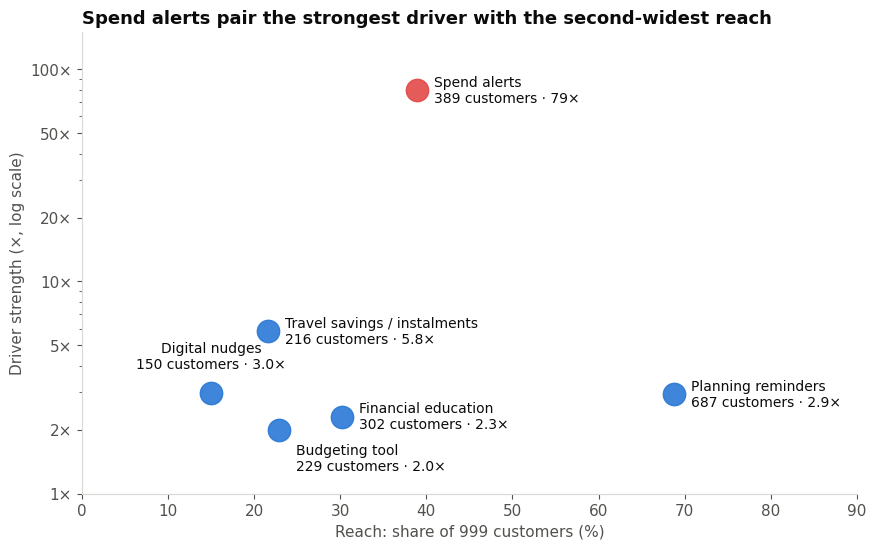

In [11]:
NAME = {'Spend alerts': 'Spend alerts', 'Financial-planning reminders': 'Planning reminders',
        'Budgeting tools': 'Budgeting tool', 'Financial-education content': 'Financial education',
        'Digital-channel nudges': 'Digital nudges', 'Product suggestions': 'Travel savings / instalments'}
OFFSET = {'Digital-channel nudges': ((0, 16), 'center', 'bottom'),
          'Budgeting tools': ((12, -10), 'left', 'top')}
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in plan.iterrows():
    top = r['tool'] == 'Spend alerts'
    ax.scatter(r['pct_of_999'], r['driver_x'], s=260, color=RED if top else BLUE, alpha=0.9, zorder=3)
    dx = f"{r['driver_x']:.0f}×" if r['driver_x'] >= 10 else f"{r['driver_x']:.1f}×"
    off, ha, va = OFFSET.get(r['tool'], ((12, 0), 'left', 'center'))
    ax.annotate(f"{NAME[r['tool']]}\n{r['customers']} customers · {dx}",
                (r['pct_of_999'], r['driver_x']), xytext=off, textcoords='offset points',
                fontsize=10, color=INK, ha=ha, va=va)
ax.set_yscale('log')
ax.set_yticks([1, 2, 5, 10, 20, 50, 100]); ax.set_yticklabels(['1×', '2×', '5×', '10×', '20×', '50×', '100×'])
ax.set_ylim(1, 150); ax.set_xlim(0, 90)
ax.set_xlabel('Reach: share of 999 customers (%)')
ax.set_ylabel('Driver strength (×, log scale)')
ax.set_title('Spend alerts pair the strongest driver with the second-widest reach')
save(fig, 's22_priority_matrix')

Biểu đồ đặt mỗi đề xuất theo hai trục: trục ngang là độ phủ, trục dọc là mức độ mạnh (thang log, vì cảnh báo chi tiêu mạnh hơn hẳn phần còn lại). Đề xuất càng gần góc trên bên phải càng nên làm trước. Cảnh báo chi tiêu tô đỏ vì là đề xuất duy nhất vừa rất mạnh vừa phủ rộng.

## Phần 3 – Độ phủ chung và phần trùng giữa các đề xuất

Một khách có thể thuộc nhiều nhóm mục tiêu. Đếm số khách duy nhất được ít nhất một đề xuất chạm tới, và số đề xuất mỗi khách nhận, để ITB không gửi quá nhiều thông điệp cho cùng một người.

In [12]:
targets = {'spend_alert': target_alert, 'planning_reminder': target_plan, 'budgeting_tool': target_budget,
           'education_content': target_edu, 'digital_nudge': target_digital, 'product_suggestion': target_product}
flags = pd.DataFrame({k: cust.index.isin(list(v)) for k, v in targets.items()}, index=cust.index)
flags['alert_priority'] = flags.index.isin(list(priority_alert))
flags['instalment_eligible'] = flags['product_suggestion'] & ~cust['under_18']
flags['n_actions'] = flags[list(targets)].sum(axis=1)
flags.to_csv(OUT / 'task5_customer_targets.csv', encoding='utf-8-sig')

any_reach = set(flags.index[flags['n_actions'] > 0])
print('Khách nhận ít nhất một đề xuất:', reach(any_reach))
print('Khách không thuộc nhóm nào:', reach(set(flags.index[flags['n_actions'] == 0])))
dist = flags['n_actions'].value_counts().sort_index()
print('\nSố đề xuất mỗi khách nhận:')
print(pd.DataFrame({'số khách': dist, '% trên 999': (dist / N_ALL * 100).round(1)}).to_string())
print('\nKhách nhận từ 4 đề xuất trở lên:', reach(set(flags.index[flags['n_actions'] >= 4])))

Khách nhận ít nhất một đề xuất: 89.4% (893 / 999)
Khách không thuộc nhóm nào: 10.6% (106 / 999)

Số đề xuất mỗi khách nhận:
           số khách  % trên 999
n_actions                      
0               106        10.6
1               302        30.2
2               264        26.4
3               202        20.2
4                88         8.8
5                37         3.7

Khách nhận từ 4 đề xuất trở lên: 12.5% (125 / 999)


Sáu đề xuất chạm tới 893 khách, chiếm 89,4% (893 / 999). 106 khách, chiếm 10,6% (106 / 999), không thuộc nhóm nào: đây là những khách không có dấu hiệu nào mà các đề xuất nhắm tới, nên không cần gửi thêm thông điệp.

Phần lớn khách nhận từ 1 đến 3 đề xuất. 125 khách, chiếm 12,5% (125 / 999), thuộc từ 4 nhóm trở lên. Với những khách này, ITB nên gửi theo thứ tự ưu tiên ở Phần 2 và giới hạn số thông điệp mỗi tháng, để hỗ trợ không trở thành làm phiền. File `outputs/task5_customer_targets.csv` đánh dấu từng khách thuộc nhóm nào, dùng trực tiếp để lên danh sách gửi.

Để thấy kế hoạch này nối với cách chia nhóm của Task 4, bảng dưới cho biết mỗi nhóm khách của Task 4 được từng đề xuất chạm tới bao nhiêu phần trăm.

In [13]:
seg_map = seg.set_index('consumer_id')['segment_name']
SEG_SHORT = {
    'Financially Stable & Highly Engaged': 'Stable & Engaged',
    'Financially Stretched but Highly Engaged': 'Stretched & Engaged',
    'Emerging Digital Customers': 'Emerging Digital',
    'Lower Engagement & Financially Pressured': 'Lower Engagement',
    'Limited-History Customers': 'Limited History',
}
by_seg = flags[list(targets)].assign(segment=flags.index.map(seg_map).map(SEG_SHORT))
seg_tab = by_seg.groupby('segment').mean() * 100
seg_tab['số khách'] = by_seg.groupby('segment').size()
seg_tab['% nhận ≥1 đề xuất'] = (by_seg[list(targets)].any(axis=1).groupby(by_seg['segment']).mean() * 100)
seg_tab['số khách từng dưới 40'] = cust['ever_below_40'].groupby(by_seg['segment']).sum().astype(int)
print('Mỗi ô = % khách trong nhóm Task 4 thuộc nhóm mục tiêu của đề xuất đó (trên số khách của nhóm):')
display(seg_tab.round(1))
seg_tab.round(1).to_csv(OUT / 'task5_reach_by_task4_segment.csv', encoding='utf-8-sig')

Mỗi ô = % khách trong nhóm Task 4 thuộc nhóm mục tiêu của đề xuất đó (trên số khách của nhóm):


,spend_alert,planning_reminder,budgeting_tool,education_content,digital_nudge,product_suggestion,số khách,% nhận ≥1 đề xuất,số khách từng dưới 40
segment,,,,,,,,,
Emerging Digital,5.7,77.3,9.7,29.5,2.8,4.0,176,81.8,0
Limited History,9.9,0.0,0.0,36.3,100.0,0.0,91,100.0,1
Lower Engagement,64.1,75.8,0.0,32.8,19.7,22.2,198,98.0,34
Stable & Engaged,35.3,61.3,1.2,19.9,4.6,25.2,326,78.5,4
Stretched & Engaged,61.5,96.6,100.0,41.8,0.0,39.9,208,100.0,31


Mọi nhóm của Task 4 đều có ít nhất 78,5% khách nhận ít nhất một đề xuất. Hai nhóm chịu áp lực tài chính nhiều nhất được phủ gần như trọn vẹn: **Stretched & Engaged** 100% và **Lower Engagement** 98,0%. Hai nhóm này cũng chứa phần lớn khách từng có tháng dưới 40 (31 và 34 khách, cột cuối của bảng).

Hai nhóm này được hỗ trợ theo hai cách khác nhau, đúng với khác biệt Task 4 đã chỉ ra:

- **Stretched & Engaged** (tương tác cao) nhận công cụ lập ngân sách trong app (100%, vì cả nhóm là một phần của nhóm mục tiêu) và nhắc kế hoạch (96,6%).
- **Lower Engagement** (tương tác thấp hơn) không nằm trong nhóm công cụ lập ngân sách (0%), mà chủ yếu nhận cảnh báo chi tiêu (64,1%) và nhắc kế hoạch (75,8%). Hai hình thức này đến với khách mà không cần khách tự mở công cụ. Vì nhóm này ít tương tác hơn, ITB nên gửi cảnh báo qua cả tin nhắn SMS, không chỉ thông báo trong app.

**Limited History** (91 khách chỉ có 1–2 tháng dữ liệu) được phủ 100% qua khuyến khích kênh số, vì cả nhóm là một phần của nhóm mục tiêu đề xuất này.

Hai nhóm có tỷ lệ được phủ thấp nhất là **Stable & Engaged** (78,5%) và **Emerging Digital** (81,8%), cũng là hai nhóm gần như không có dấu hiệu căng thẳng: lần lượt 4 và 0 khách từng có tháng dưới 40. Điều này hợp lý, vì kế hoạch tập trung vào nơi có vấn đề.

## Phần 4 – Quy tắc tín dụng và các kiểm tra an toàn

**Quy tắc.** financial_health_score chỉ dùng để chọn ai được hỗ trợ trước. Điểm này **không bao giờ** được dùng để từ chối cho vay, giảm hạn mức hay khóa tài khoản.

Điểm sức khỏe xuất hiện ở ba chỗ trong kế hoạch, và cả ba đều là chọn ai được hỗ trợ:

- chọn 61 khách từng có tháng dưới 40 để nhận cảnh báo chi tiêu trước (đề xuất 1);
- nhóm 64 khách của Task 2, chọn theo 25% điểm sức khỏe thấp nhất, nằm trong nhóm nhận công cụ lập ngân sách (đề xuất 3);
- nhóm 59 khách của Task 3, chọn theo 25% điểm sức khỏe cao nhất, nằm trong nhóm nhận khuyến khích kênh số (đề xuất 5).

Không chỗ nào dùng điểm để hạn chế tín dụng, đúng với quy tắc. Ô code dưới đây kiểm tra thêm hai điều kiện đo được: không khách dưới 18 tuổi nào nằm trong nhóm được gợi ý trả góp, và đủ 6 loại công cụ, mỗi đề xuất có nhóm mục tiêu với số khách cụ thể.

In [14]:
print('Khách dưới 18 tuổi trong nhóm được gợi ý trả góp:', int((flags['instalment_eligible'] & cust['under_18']).sum()))
print('Đủ 6 loại công cụ, mỗi loại một đề xuất:', plan['tool'].nunique() == 6 and len(plan) == 6)
print('Mọi đề xuất đều có nhóm mục tiêu với số khách:', bool((plan['customers'] > 0).all()))

Khách dưới 18 tuổi trong nhóm được gợi ý trả góp: 0
Đủ 6 loại công cụ, mỗi loại một đề xuất: True
Mọi đề xuất đều có nhóm mục tiêu với số khách: True


Sáu đề xuất đều chỉ đưa thêm thông tin, công cụ hoặc lựa chọn cho khách. Không đề xuất nào giảm hạn mức, từ chối hay khóa tài khoản. Trả góp là lựa chọn khách tự quyết, ghi rõ phí và không dành cho khách dưới 18 tuổi.

### Giới hạn của kế hoạch

- **Dữ liệu giả lập, chỉ một năm 2025.** Các phát hiện như tính mùa vụ tháng 12 cần được kiểm tra lại khi có dữ liệu năm sau.
- **Chỉ là quan hệ đi cùng nhau, chưa phải nhân quả.** Ví dụ, giao dịch lớn đi cùng tháng căng thẳng, nhưng dữ liệu chưa chứng minh cảnh báo sẽ làm giảm căng thẳng. Vì vậy mỗi đề xuất đều kèm cách đo, và nên chạy thử có nhóm đối chứng trước khi triển khai rộng.
- **Không có dữ liệu về sự đồng ý nhận thông báo.** Số khách mục tiêu là số khách đủ điều kiện, không phải số khách chắc chắn nhận được thông điệp.
- **Nhóm mục tiêu dựa trên hành vi năm 2025.** Khi triển khai cần tính lại theo dữ liệu mới nhất, vì Task 3 cho thấy danh sách khách thay đổi giữa hai nửa năm.

### Đối chiếu với yêu cầu của đề

| Yêu cầu của đề | Đáp ứng ở đâu |
|---|---|
| Đủ 6 loại công cụ, mỗi loại một đề xuất | Phần 1, đề xuất 1–6; kiểm tra ở Phần 4 |
| Mỗi đề xuất dựa trên một phát hiện thật, gắn với con số hoặc cột dữ liệu | Dòng "Phát hiện" của từng đề xuất, có ghi tên cột |
| Nhóm mục tiêu có số khách và tỷ lệ chính xác | Dòng "Nhóm mục tiêu"; danh sách từng khách trong `outputs/task5_customer_targets.csv` |
| Xếp hạng theo độ phủ và theo mức độ mạnh | Phần 2, bảng xếp hạng và biểu đồ `charts/s22_priority_matrix.png` |
| Không đề xuất mang tính trừng phạt | Cả 6 đề xuất chỉ thêm thông tin, công cụ hoặc lựa chọn; kiểm tra khách dưới 18 tuổi ở Phần 4 |
| Tuyên bố quy tắc tín dụng | Phần 4 và slide 21 |